In [1]:
import requests
import zipfile
import os

RAW_DIR = r"C:\Users\User\Desktop\Data Analysis\airline-performance\data\raw"
os.makedirs(RAW_DIR, exist_ok=True)

YEAR = 2025
BASE_URL = "https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip"
headers = {"User-Agent": "Mozilla/5.0"}

for month in range(1, 13):
    url = BASE_URL.format(year=YEAR, month=month)
    zip_path = os.path.join(RAW_DIR, f"ontime_{YEAR}_{month}.zip")

    print(f"Downloading month {month}...")
    response = requests.get(url, headers=headers, timeout=60)
    response.raise_for_status()

    with open(zip_path, "wb") as f:
        f.write(response.content)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(RAW_DIR)

    size_mb = len(response.content) / 1_000_000
    print(f"  Month {month}: {size_mb:.1f} MB zipped, extracted")

print("\nDone. Files saved in:", RAW_DIR)

  Month 1: 27.1 MB zipped, extracted
  Month 2: 25.3 MB zipped, extracted
  Month 3: 30.5 MB zipped, extracted
  Month 4: 29.4 MB zipped, extracted
  Month 5: 30.8 MB zipped, extracted
  Month 6: 31.1 MB zipped, extracted
  Month 7: 32.2 MB zipped, extracted
  Month 8: 30.9 MB zipped, extracted
  Month 9: 28.2 MB zipped, extracted
  Month 10: 30.7 MB zipped, extracted
  Month 11: 28.8 MB zipped, extracted


ConnectionError: HTTPSConnectionPool(host='transtats.bts.gov', port=443): Read timed out.

In [ ]:
import os
import csv

raw_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\data\raw"
files = sorted(f for f in os.listdir(raw_dir) if f.endswith(".csv"))

print(f"Found {len(files)} files\n")

total_rows = 0
columns = None

for fname in files:
    path = os.path.join(raw_dir, fname)
    with open(path, encoding="utf-8") as f:
        reader = csv.reader(f)
        header = next(reader)
        if columns is None:
            columns = header
        row_count = sum(1 for _ in reader)
    total_rows += row_count
    print(f"{fname}: {row_count:,} rows")

print(f"\nTotal columns: {len(columns)}")
print("Column names:")
print(columns)
print(f"\nTotal rows across all 12 months: {total_rows:,}")

Found 12 files

On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_1.csv: 539,747 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_10.csv: 605,844 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_11.csv: 570,550 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_12.csv: 582,304 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_2.csv: 504,884 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_3.csv: 600,872 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_4.csv: 583,950 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_5.csv: 605,648 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_6.csv: 611,575 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_7.csv: 631,428 rows
On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_8.csv: 602,378 rows
On_Time_Reporting_Carrier_On_Time_P

In [2]:
import pandas as pd

lookup_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\data\raw"
base_url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/"

airport_cols = ["airport_id","name","city","country","iata","icao",
                 "latitude","longitude","altitude","utc_offset","dst",
                 "tz_timezone","type","source"]
airline_cols = ["airline_id","name","alias","iata","icao","callsign","country","active"]

airports = pd.read_csv(base_url + "airports.dat", header=None, names=airport_cols, na_values=["\\N"])
airlines = pd.read_csv(base_url + "airlines.dat", header=None, names=airline_cols, na_values=["\\N"])

airports.to_csv(lookup_dir + r"\airports_lookup.csv", index=False)
airlines.to_csv(lookup_dir + r"\airlines_lookup.csv", index=False)

print(f"Airports lookup: {len(airports):,} rows")
print(f"Airlines lookup: {len(airlines):,} rows")

Airports lookup: 7,698 rows
Airlines lookup: 6,162 rows


In [3]:
import dask.dataframe as dd

raw_glob = r"C:\Users\User\Desktop\Data Analysis\airline-performance\data\raw\On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_*.csv"

keep_cols = [
    "Year","Quarter","Month","DayofMonth","DayOfWeek","FlightDate",
    "Reporting_Airline","Tail_Number","Flight_Number_Reporting_Airline",
    "Origin","OriginCityName","OriginState",
    "Dest","DestCityName","DestState",
    "CRSDepTime","DepTime","DepDelay","DepDelayMinutes","DepDel15","DepTimeBlk",
    "TaxiOut","WheelsOff","WheelsOn","TaxiIn",
    "CRSArrTime","ArrTime","ArrDelay","ArrDelayMinutes","ArrDel15","ArrTimeBlk",
    "Cancelled","CancellationCode","Diverted",
    "CRSElapsedTime","ActualElapsedTime","AirTime",
    "Distance","DistanceGroup",
    "CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay"
]

dtype_map = {c: "object" for c in [
    "Tail_Number","CancellationCode","Reporting_Airline","Origin","Dest",
    "OriginCityName","OriginState","DestCityName","DestState","DepTimeBlk","ArrTimeBlk"
]}

ddf = dd.read_csv(raw_glob, usecols=keep_cols, dtype=dtype_map, assume_missing=True)

print("Columns kept:", len(ddf.columns), "of 110")

processed_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\data\processed"
ddf.to_parquet(processed_dir + r"\flights_trimmed.parquet", engine="pyarrow", write_index=False)

print("Trim complete.")

Columns kept: 44 of 110
Trim complete.


In [4]:
lookup_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\data\raw"
processed_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\data\processed"

df = pd.read_parquet(processed_dir + r"\flights_trimmed.parquet")
print(f"Rows: {len(df):,}")  # should read 7,001,619

int_cols = ["Year","Quarter","Month","DayofMonth","DayOfWeek","CRSDepTime","DepTime","DepDel15",
            "WheelsOff","WheelsOn","CRSArrTime","ArrTime","ArrDel15","DistanceGroup"]
for col in int_cols:
    df[col] = df[col].astype("Int64")

df["Cancelled"] = df["Cancelled"].fillna(0).astype(int).astype(bool)
df["Diverted"] = df["Diverted"].fillna(0).astype(int).astype(bool)
df["FlightDate"] = pd.to_datetime(df["FlightDate"]).dt.date

delay_cause_cols = ["CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay"]
minor_delay_mask = (df["ArrDelayMinutes"] < 15) & (~df["Cancelled"]) & (~df["Diverted"])
for col in delay_cause_cols:
    df.loc[minor_delay_mask, col] = df.loc[minor_delay_mask, col].fillna(0)

def categorize(row):
    if row["Cancelled"]: return "Cancelled"
    if row["Diverted"]: return "Diverted"
    if pd.isna(row["ArrDelayMinutes"]): return "Unknown"
    if row["ArrDelayMinutes"] < 15: return "On-time"
    if row["ArrDelayMinutes"] < 60: return "Minor"
    if row["ArrDelayMinutes"] < 120: return "Moderate"
    return "Severe"

df["DelayCategory"] = df.apply(categorize, axis=1)
print(df["DelayCategory"].value_counts())

origin_codes = set(df["Origin"].unique())
dest_codes = set(df["Dest"].unique())
carrier_codes = set(df["Reporting_Airline"].unique())
needed_airport_codes = origin_codes | dest_codes

airports_lookup = pd.read_csv(lookup_dir + r"\airports_lookup.csv")
airlines_lookup = pd.read_csv(lookup_dir + r"\airlines_lookup.csv")

airports_db = airports_lookup[airports_lookup["iata"].isin(needed_airport_codes)].drop_duplicates(subset="iata").copy()
airports_db = airports_db.rename(columns={"iata":"airport_code","name":"airport_name","tz_timezone":"timezone"})[
    ["airport_code","airport_name","city","country","latitude","longitude","timezone"]]

state_lookup = pd.concat([
    df[["Origin","OriginState"]].rename(columns={"Origin":"airport_code","OriginState":"state"}),
    df[["Dest","DestState"]].rename(columns={"Dest":"airport_code","DestState":"state"})
]).drop_duplicates(subset="airport_code")
airports_db = airports_db.merge(state_lookup, on="airport_code", how="left")

airlines_db = airlines_lookup[(airlines_lookup["active"]=="Y") & (airlines_lookup["iata"].isin(carrier_codes))].drop_duplicates(subset="iata").copy()
airlines_db = airlines_db.rename(columns={"iata":"airline_code","name":"airline_name"})[["airline_code","airline_name","country"]]

missing_airports = needed_airport_codes - set(airports_db["airport_code"])
missing_airlines = carrier_codes - set(airlines_db["airline_code"])
print(f"\nAirports matched: {len(airports_db)} of {len(needed_airport_codes)}")
print(f"Airlines matched: {len(airlines_db)} of {len(carrier_codes)}")
print("Unmatched airport codes:", missing_airports)
print("Unmatched airline codes:", missing_airlines)

load_columns = ["FlightDate","Reporting_Airline","Tail_Number","Flight_Number_Reporting_Airline",
    "Origin","Dest","CRSDepTime","DepTime","DepDelay","DepDelayMinutes","DepDel15","DepTimeBlk",
    "TaxiOut","WheelsOff","WheelsOn","TaxiIn","CRSArrTime","ArrTime","ArrDelay","ArrDelayMinutes","ArrDel15","ArrTimeBlk",
    "Cancelled","CancellationCode","Diverted","CRSElapsedTime","ActualElapsedTime","AirTime",
    "Distance","DistanceGroup","CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay","DelayCategory"]

df_mysql = df[load_columns].copy()
df_mysql["Cancelled"] = df_mysql["Cancelled"].astype(int)
df_mysql["Diverted"] = df_mysql["Diverted"].astype(int)
df_mysql.to_csv(processed_dir + r"\flights_load_ready.csv", index=False, na_rep="\\N")

airports_db.to_csv(processed_dir + r"\airports_db.csv", index=False)
airlines_db.to_csv(processed_dir + r"\airlines_db.csv", index=False)
print("\nMySQL-ready files written.")

Rows: 7,001,619
DelayCategory
On-time      5344846
Minor         972084
Moderate      331282
Severe        231272
Cancelled     102876
Diverted       19258
Unknown            1
Name: count, dtype: int64

Airports matched: 350 of 352
Airlines matched: 14 of 14
Unmatched airport codes: {'XWA', 'EAR'}
Unmatched airline codes: set()

MySQL-ready files written.


In [5]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv(r"C:\Users\User\Desktop\Data Analysis\airline-performance\.env")
conn_str = f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DATABASE')}"
engine = create_engine(conn_str)
images_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\images"

airport_query = """
SELECT ap.airport_name, ap.city, ap.state, ap.latitude, ap.longitude,
    COUNT(*) AS total_flights, AVG(o.arr_delay_minutes) AS avg_arr_delay
FROM flights o JOIN airports ap ON o.origin_code = ap.airport_code
GROUP BY ap.airport_name, ap.city, ap.state, ap.latitude, ap.longitude
HAVING COUNT(*) >= 500
"""
airport_geo = pd.read_sql(airport_query, engine)
geometry = [Point(xy) for xy in zip(airport_geo["longitude"], airport_geo["latitude"])]
airport_gdf = gpd.GeoDataFrame(airport_geo, geometry=geometry, crs="EPSG:4326")
fig2 = px.scatter_geo(airport_gdf, lat=airport_gdf.geometry.y, lon=airport_gdf.geometry.x,
    size="total_flights", color="avg_arr_delay", color_continuous_scale="RdYlGn_r",
    hover_name="airport_name", scope="usa", title="Average Arrival Delay by Airport (500+ flights)")
fig2.write_image(images_dir + r"\airport_delay_map.png", width=1000, height=650, scale=2)

ts_df = pd.read_sql("SELECT flight_date, AVG(arr_delay_minutes) AS avg_delay FROM flights WHERE cancelled=0 AND diverted=0 GROUP BY flight_date ORDER BY flight_date", engine)
fig3 = go.Figure(go.Scatter(x=ts_df["flight_date"], y=ts_df["avg_delay"], mode="lines"))
fig3.update_layout(title="Average Arrival Delay by Day, 2025", xaxis_title="Date", yaxis_title="Minutes")
fig3.write_image(images_dir + r"\delay_time_series.png", width=1000, height=500, scale=2)
print("Saved both as static PNGs.")

Saved both as static PNGs.


In [ ]:
import mysql.connector

conn = mysql.connector.connect(
    host=os.getenv("MYSQL_HOST"), port=os.getenv("MYSQL_PORT"),
    user=os.getenv("MYSQL_USER"), password=os.getenv("MYSQL_PASSWORD"),
    database=os.getenv("MYSQL_DATABASE"), allow_local_infile=True
)
cur = conn.cursor()

load_sql = """
LOAD DATA LOCAL INFILE 'C:/Users/User/Desktop/Data Analysis/airline-performance/data/processed/flights_load_ready.csv'
INTO TABLE flights
FIELDS TERMINATED BY ',' OPTIONALLY ENCLOSED BY '"'
LINES TERMINATED BY '\\n'
IGNORE 1 LINES
(flight_date, airline_code, tail_number, flight_number, origin_code, dest_code,
 crs_dep_time, dep_time, dep_delay, dep_delay_minutes, dep_del15, dep_time_blk,
 taxi_out, wheels_off, wheels_on, taxi_in, crs_arr_time, arr_time, arr_delay, arr_delay_minutes, arr_del15, arr_time_blk,
 cancelled, cancellation_code, diverted, crs_elapsed_time, actual_elapsed_time, air_time,
 distance, distance_group, carrier_delay, weather_delay, nas_delay, security_delay, late_aircraft_delay, delay_category)
"""

cur.execute(load_sql)
conn.commit()
print(f"Rows loaded: {cur.rowcount:,}")
cur.close()
conn.close()

Rows loaded: 7,001,619


In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv(r"C:\Users\User\Desktop\Data Analysis\airline-performance\.env")
conn_str = f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DATABASE')}"
engine = create_engine(conn_str)

query = """
SELECT
    f.flight_id, f.flight_date, f.origin_code, f.dest_code,
    f.dep_time, f.arr_time, f.actual_elapsed_time,
    o.timezone AS origin_timezone, d.timezone AS dest_timezone
FROM flights f
JOIN airports o ON f.origin_code = o.airport_code
JOIN airports d ON f.dest_code = d.airport_code
WHERE f.cancelled = 0 AND f.diverted = 0
"""
tz_df = pd.read_sql(query, engine)
print(f"Rows pulled: {len(tz_df):,}")

def hhmm_to_timedelta(hhmm_series):
    # BTS stores times as HHMM integers; 2400 sometimes means midnight-next-day
    hhmm = hhmm_series.fillna(0).astype(int)
    hour = (hhmm // 100) % 24
    minute = hhmm % 100
    overflow_days = (hhmm // 2400).astype(int)
    return pd.to_timedelta(hour, unit="h") + pd.to_timedelta(minute, unit="m") + pd.to_timedelta(overflow_days, unit="D")

def localize_to_utc(date_series, hhmm_series, tz_series):
    naive = pd.to_datetime(date_series) + hhmm_to_timedelta(hhmm_series)
    result = pd.Series(pd.NaT, index=naive.index, dtype="datetime64[ns, UTC]")
    for tz in tz_series.dropna().unique():
        mask = (tz_series == tz).values
        localized = naive[mask].dt.tz_localize(tz, ambiguous="NaT", nonexistent="shift_forward")
        result[mask] = localized.dt.tz_convert("UTC")
    return result

tz_df["dep_time_utc"] = localize_to_utc(tz_df["flight_date"], tz_df["dep_time"], tz_df["origin_timezone"])
tz_df["arr_time_utc"] = localize_to_utc(tz_df["flight_date"], tz_df["arr_time"], tz_df["dest_timezone"])

tz_df["computed_elapsed_minutes"] = (tz_df["arr_time_utc"] - tz_df["dep_time_utc"]).dt.total_seconds() / 60
tz_df.loc[tz_df["computed_elapsed_minutes"] < 0, "computed_elapsed_minutes"] += 1440  # rare date-rollover edge case

tz_df["elapsed_diff"] = (tz_df["computed_elapsed_minutes"] - tz_df["actual_elapsed_time"]).abs()

print("\nComputed vs. BTS-reported elapsed time, difference in minutes:")
print(tz_df["elapsed_diff"].describe())
print(f"\nRows differing by more than 5 minutes: {(tz_df['elapsed_diff'] > 5).sum():,}")

processed_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\data\processed"
tz_df.to_parquet(processed_dir + r"\flights_timezone_corrected.parquet")
print("Saved.")

Rows pulled: 6,879,485

Computed vs. BTS-reported elapsed time, difference in minutes:
count    6.878777e+06
mean     9.511662e-02
std      1.074598e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.440000e+03
Name: elapsed_diff, dtype: float64

Rows differing by more than 5 minutes: 2,193
Saved.


In [ ]:
# The 708 rows that dropped to NaN
nan_rows = tz_df[tz_df["elapsed_diff"].isna()]
print(nan_rows["flight_date"].value_counts().head(10))

# The rare ~24-hour outliers pulling the max up to 1440
extreme_rows = tz_df[tz_df["elapsed_diff"] > 1000]
print(f"Count: {len(extreme_rows)}")
print(extreme_rows[["flight_date","origin_code","dest_code","dep_time","arr_time"]].head(10))

flight_date
2025-11-02    113
2025-12-20      8
2025-12-27      8
2025-12-28      5
2025-12-19      5
2025-12-21      5
2025-12-26      5
2025-01-01      4
2025-01-02      4
2025-01-03      4
Name: count, dtype: int64
Count: 380
       flight_date origin_code dest_code  dep_time  arr_time
119362  2025-01-01         ATL       BHM         2    2346.0
207648  2025-01-28         GUM       HNL       711    1818.0
209679  2025-01-27         GUM       HNL       719    1819.0
211700  2025-01-26         GUM       HNL       721    1755.0
213558  2025-01-18         GUM       HNL       749    1838.0
215602  2025-01-17         GUM       HNL       722    1832.0
217646  2025-01-16         GUM       HNL       725    1820.0
219590  2025-01-15         GUM       HNL       749    1845.0
221202  2025-01-04         GUM       HNL       751    1849.0
223335  2025-01-03         GUM       HNL       812    1927.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv(r"C:\Users\User\Desktop\Data Analysis\airline-performance\.env")
conn_str = f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}@{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT')}/{os.getenv('MYSQL_DATABASE')}"
engine = create_engine(conn_str)
images_dir = r"C:\Users\User\Desktop\Data Analysis\airline-performance\images"

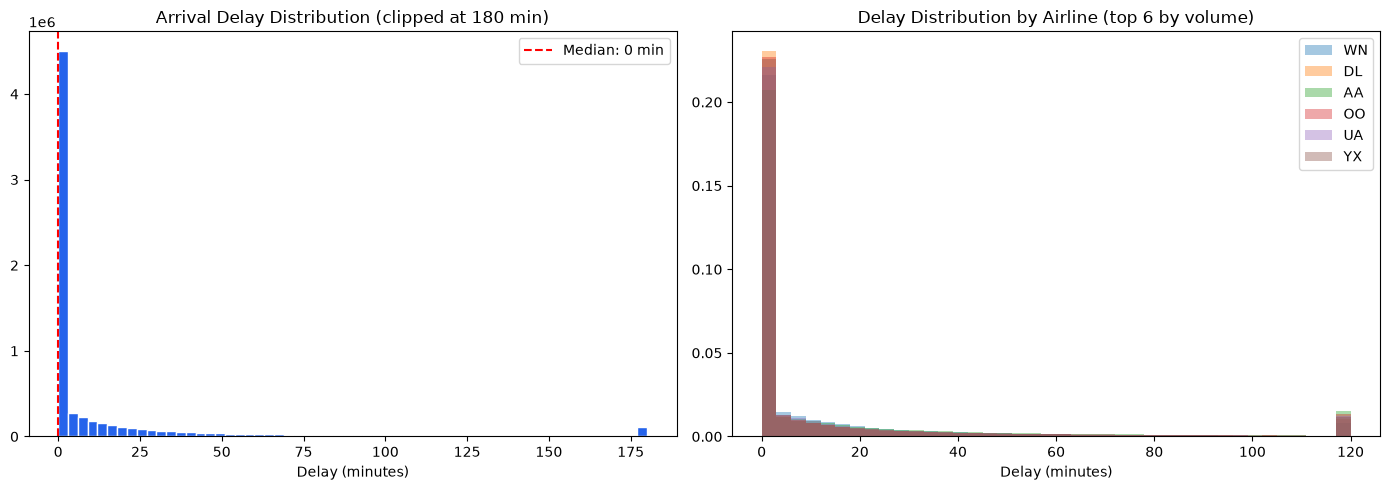

Mean: 17.3 | Median: 0.0 | Skew: 10.93


In [ ]:
delay_query = """
SELECT airline_code, arr_delay_minutes
FROM flights
WHERE cancelled = 0 AND diverted = 0 AND arr_delay_minutes IS NOT NULL
"""
delay_df = pd.read_sql(delay_query, engine)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(delay_df["arr_delay_minutes"].clip(upper=180), bins=60, color="#2563eb", edgecolor="white")
axes[0].axvline(delay_df["arr_delay_minutes"].median(), color="red", linestyle="--",
                 label=f"Median: {delay_df['arr_delay_minutes'].median():.0f} min")
axes[0].set_title("Arrival Delay Distribution (clipped at 180 min)")
axes[0].set_xlabel("Delay (minutes)"); axes[0].legend()

top_airlines = delay_df["airline_code"].value_counts().head(6).index
for al in top_airlines:
    subset = delay_df[delay_df["airline_code"] == al]["arr_delay_minutes"].clip(upper=120)
    axes[1].hist(subset, bins=40, alpha=0.4, label=al, density=True)
axes[1].set_title("Delay Distribution by Airline (top 6 by volume)")
axes[1].set_xlabel("Delay (minutes)"); axes[1].legend()

plt.tight_layout()
plt.savefig(images_dir + r"\delay_distributions.png", dpi=150)
plt.show()

print(f"Mean: {delay_df['arr_delay_minutes'].mean():.1f} | Median: {delay_df['arr_delay_minutes'].median():.1f} | Skew: {delay_df['arr_delay_minutes'].skew():.2f}")

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px

airport_query = """
SELECT ap.airport_name, ap.city, ap.state, ap.latitude, ap.longitude,
    COUNT(*) AS total_flights, AVG(o.arr_delay_minutes) AS avg_arr_delay
FROM flights o
JOIN airports ap ON o.origin_code = ap.airport_code
GROUP BY ap.airport_name, ap.city, ap.state, ap.latitude, ap.longitude
HAVING COUNT(*) >= 500
"""
airport_geo = pd.read_sql(airport_query, engine)

geometry = [Point(xy) for xy in zip(airport_geo["longitude"], airport_geo["latitude"])]
airport_gdf = gpd.GeoDataFrame(airport_geo, geometry=geometry, crs="EPSG:4326")

fig2 = px.scatter_geo(airport_gdf, lat=airport_gdf.geometry.y, lon=airport_gdf.geometry.x,
    size="total_flights", color="avg_arr_delay", color_continuous_scale="RdYlGn_r",
    hover_name="airport_name", hover_data={"city": True, "state": True},
    scope="usa", title="Average Arrival Delay by Airport (500+ flights)")
fig2.write_html(images_dir + r"\airport_delay_map.html")
fig2.show()

In [ ]:
import plotly.graph_objects as go

ts_query = """
SELECT flight_date, AVG(arr_delay_minutes) AS avg_delay
FROM flights WHERE cancelled = 0 AND diverted = 0
GROUP BY flight_date ORDER BY flight_date
"""
ts_df = pd.read_sql(ts_query, engine)

fig3 = go.Figure(go.Scatter(x=ts_df["flight_date"], y=ts_df["avg_delay"], mode="lines"))
fig3.update_layout(title="Average Arrival Delay by Day, 2025", xaxis_title="Date", yaxis_title="Minutes")
fig3.write_html(images_dir + r"\delay_time_series.html")
fig3.show()

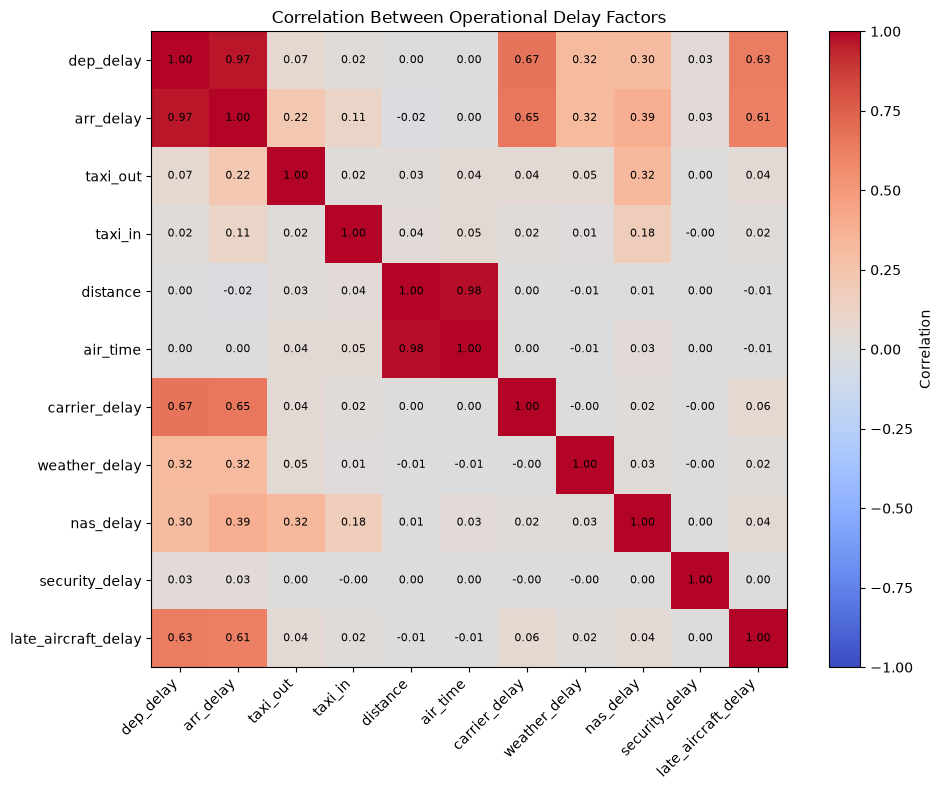

In [ ]:
corr_query = """
SELECT dep_delay, arr_delay, taxi_out, taxi_in, distance, air_time,
    carrier_delay, weather_delay, nas_delay, security_delay, late_aircraft_delay
FROM flights WHERE flight_id % 10 = 0 AND cancelled = 0 AND diverted = 0
"""
corr_df = pd.read_sql(corr_query, engine)
corr_matrix = corr_df.corr()

fig4, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns))); ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Correlation")
plt.title("Correlation Between Operational Delay Factors")
plt.tight_layout()
plt.savefig(images_dir + r"\correlation_heatmap.png", dpi=150)
plt.show()